# Bodrum Hotel & Destination Intelligence
## 09 - Tourism Demand Analysis

Bu notebook turizm talebini üç ayrı grain ve coğrafi kapsamda inceler:

1. **Muğla ili, 2009–2025, yıllık:** uzun dönem talep trendi.
2. **Muğla ili, 2025, aylık:** tek yıl içindeki sezonluk talep deseni.
3. **Bodrum ilçesi, 2025, yıllık:** Bodrum'un yıllık ziyaretçi/konaklama profili.

> Muğla 2025 aylık serisi hiçbir noktada “Bodrum aylık turizm talebi” olarak sunulmaz. Bodrum için
> bu aşamada yalnızca 2025 yıllık ilçe verisi vardır.

Analiz tamamen descriptive/exploratory'dir. Forecasting, seasonal decomposition, STL, ARIMA,
SARIMA, Prophet, LSTM, makine öğrenmesi, kümeleme veya anomali modeli uygulanmaz.


### 1. Kurulum, gerçek dosya yolları ve kaynak bütünlüğü

In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.tourism_demand import (
    CORE_FLOW_COLUMNS,
    MONTH_ORDER_TR,
    add_annual_features,
    add_monthly_features,
    bodrum_profile,
    bodrum_vs_mugla_profile,
    dataset_quality_audit,
    monthly_correlations,
    period_summary,
    season_group_summary,
    seasonality_metrics,
)

MONTHLY_PATH = PROJECT_ROOT / "data" / "external" / "tourism" / "tourism_demand_monthly_mugla_2025.csv"
ANNUAL_PATH = PROJECT_ROOT / "data" / "external" / "tourism" / "tourism_demand_annual_mugla_2009_2025.csv"
BODRUM_PATH = PROJECT_ROOT / "data" / "external" / "tourism" / "tourism_demand_bodrum_annual_2025.csv"
DESTINATION_CONTEXT_PATH = PROJECT_ROOT / "data" / "processed" / "destination_intelligence_enriched.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "tourism_demand"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [MONTHLY_PATH, ANNUAL_PATH, BODRUM_PATH]
if DESTINATION_CONTEXT_PATH.exists():
    required_paths.append(DESTINATION_CONTEXT_PATH)
assert all(path.exists() for path in required_paths), "Turizm talebi girdilerinden biri eksik."
input_hashes_before = {path: hashlib.sha256(path.read_bytes()).hexdigest() for path in required_paths}

monthly_raw = pd.read_csv(MONTHLY_PATH)
annual_raw = pd.read_csv(ANNUAL_PATH)
bodrum_raw = pd.read_csv(BODRUM_PATH)
destination_context = pd.read_csv(DESTINATION_CONTEXT_PATH) if DESTINATION_CONTEXT_PATH.exists() else None

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print("Muğla monthly 2025:", monthly_raw.shape)
print("Muğla annual 2009–2025:", annual_raw.shape)
print("Bodrum annual 2025:", bodrum_raw.shape)


Muğla monthly 2025: (12, 18)
Muğla annual 2009–2025: (17, 14)
Bodrum annual 2025: (1, 14)


In [2]:
PRIMARY = "#2F6B7C"
SECONDARY = "#4C956C"
ACCENT = "#C1666B"
HIGHLIGHT = "#D9A404"
PURPLE = "#7A5C8E"
NEUTRAL = "#777777"


def save_fig(fig, filename):
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def millions_axis(ax):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f"{x / 1_000_000:.1f}M"))


def line_chart(x, y, title, ylabel, filename, color=PRIMARY, marker="o"):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.plot(x, y, color=color, marker=marker, linewidth=2.2)
    ax.set(title=title, xlabel="Yıl", ylabel=ylabel)
    ax.grid(alpha=0.22)
    ax.set_xticks(x)
    ax.tick_params(axis="x", rotation=45)
    save_fig(fig, filename)


def monthly_chart(frame, columns, title, ylabel, filename, colors):
    fig, ax = plt.subplots(figsize=(11, 5.7))
    for column, color in zip(columns, colors):
        ax.plot(frame["month_name_tr"].astype(str), frame[column], marker="o", linewidth=2.1,
                color=color, label=column.replace("_", " ").title())
    ax.set(title=title, xlabel="Ay", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=40)
    ax.grid(alpha=0.22)
    if len(columns) > 1:
        ax.legend()
    save_fig(fig, filename)


### 2. Source / grain audit

In [3]:
input_summary = pd.DataFrame([
    {
        "dataset_name": "Muğla Monthly 2025", "row_count": len(monthly_raw), "column_count": monthly_raw.shape[1],
        "geography": monthly_raw["geography"].iloc[0], "geography_level": monthly_raw["geography_level"].iloc[0],
        "time_grain": "monthly", "start_period": monthly_raw["period"].min(), "end_period": monthly_raw["period"].max(),
        "source_origin": monthly_raw["source_origin"].iloc[0],
    },
    {
        "dataset_name": "Muğla Annual 2009–2025", "row_count": len(annual_raw), "column_count": annual_raw.shape[1],
        "geography": annual_raw["geography"].iloc[0], "geography_level": annual_raw["geography_level"].iloc[0],
        "time_grain": "annual", "start_period": int(annual_raw["year"].min()), "end_period": int(annual_raw["year"].max()),
        "source_origin": annual_raw["source_origin"].iloc[0],
    },
    {
        "dataset_name": "Bodrum Annual 2025", "row_count": len(bodrum_raw), "column_count": bodrum_raw.shape[1],
        "geography": bodrum_raw["geography"].iloc[0], "geography_level": bodrum_raw["geography_level"].iloc[0],
        "time_grain": "annual", "start_period": int(bodrum_raw["year"].min()), "end_period": int(bodrum_raw["year"].max()),
        "source_origin": bodrum_raw["source_origin"].iloc[0],
    },
], columns=["dataset_name", "row_count", "column_count", "geography", "geography_level", "time_grain", "start_period", "end_period", "source_origin"])
display(input_summary)


,dataset_name,row_count,column_count,geography,geography_level,time_grain,start_period,end_period,source_origin
0,Muğla Monthly 2025,12,18,Muğla,province,monthly,2025-01,2025-12,T.C. Kültür ve Turizm Bakanlığı konaklama istatistikleri
1,Muğla Annual 2009–2025,17,14,Muğla,province,annual,2009,2025,T.C. Kültür ve Turizm Bakanlığı
2,Bodrum Annual 2025,1,14,Bodrum,district,annual,2025,2025,T.C. Kültür ve Turizm Bakanlığı ilçe konaklama istatistikleri


In [4]:
assert set(monthly_raw["geography"]) == {"Muğla"}
assert set(monthly_raw["geography_level"]) == {"province"}
assert set(annual_raw["geography"]) == {"Muğla"}
assert set(annual_raw["geography_level"]) == {"province"}
assert set(bodrum_raw["geography"]) == {"Bodrum"}
assert set(bodrum_raw["geography_level"]) == {"district"}
display(Markdown(
    "**Metodolojik ayrım:** İlk iki kaynak Muğla **il**, üçüncü kaynak Bodrum **ilçe** düzeyindedir. "
    "Muğla aylık seri Bodrum'a dağıtılamaz; 14 destinasyonla aylık join yapılmaz."
))


**Metodolojik ayrım:** İlk iki kaynak Muğla **il**, üçüncü kaynak Bodrum **ilçe** düzeyindedir. Muğla aylık seri Bodrum'a dağıtılamaz; 14 destinasyonla aylık join yapılmaz.

### 3. Veri kalitesi ve türetilmiş metrik doğrulaması

In [5]:
quality_checks = pd.concat([
    dataset_quality_audit(
        monthly_raw, "Muğla Monthly 2025", "period",
        occupancy_column="occupancy_rate_pct", average_stay_column="derived_avg_stay_nights",
    ),
    dataset_quality_audit(
        annual_raw, "Muğla Annual 2009–2025", "year",
        occupancy_column="occupancy_rate_pct", average_stay_column="avg_stay_nights",
    ),
    dataset_quality_audit(
        bodrum_raw, "Bodrum Annual 2025", "year",
        occupancy_column=None, average_stay_column="derived_avg_stay_nights",
    ),
], ignore_index=True)
display(quality_checks)


,dataset_name,check,value,status
0,Muğla Monthly 2025,row_count,12.0000,INFO
1,Muğla Monthly 2025,column_count,18.0000,INFO
2,Muğla Monthly 2025,missing_cells,0.0000,PASS
3,Muğla Monthly 2025,duplicate_rows,0.0000,PASS
4,Muğla Monthly 2025,duplicate_period,0.0000,PASS
5,Muğla Monthly 2025,invalid_numeric_cells,0.0000,PASS
6,Muğla Monthly 2025,negative_numeric_values,0.0000,PASS
7,Muğla Monthly 2025,arrival_total_mismatch_rows,0.0000,PASS
8,Muğla Monthly 2025,max_abs_arrival_total_difference,0.0000,PASS
9,Muğla Monthly 2025,occupancy_out_of_0_100_rows,0.0000,PASS


In [6]:
annual_features = add_annual_features(annual_raw)
mugla_2025 = annual_features.loc[annual_features["year"].eq(2025)].iloc[0]
monthly_features, monthly_metadata = add_monthly_features(monthly_raw, mugla_2025)
bodrum_2025 = bodrum_profile(bodrum_raw)
display(pd.DataFrame([monthly_metadata]))
display(annual_features[["year", "arrival_total_difference", "avg_stay_difference", "foreign_share_difference_pp"]])
display(monthly_features[["period", "arrival_total_difference", "avg_stay_difference", "foreign_share_difference_pp"]])
display(bodrum_2025[["year", "arrival_total_difference", "avg_stay_difference", "foreign_share_difference_pp"]])


,monthly_totals_match_annual_2025,share_denominator_source,arrival_share_denominator,overnight_share_denominator,season_q33_total_arrivals,season_q67_total_arrivals,domestic_arrivals_monthly_minus_annual,foreign_arrivals_monthly_minus_annual,total_arrivals_monthly_minus_annual,total_overnights_monthly_minus_annual
0,True,annual_2025_official_total_matches_monthly_sum,9129867,24669490,"300,451.0000","932,149.3333",0,0,0,0


,year,arrival_total_difference,avg_stay_difference,foreign_share_difference_pp
0,2009,0,-0.0011,-0.0020
1,2010,0,0.0032,-0.0005
2,2011,0,0.0015,0.0034
3,2012,0,0.0036,0.0002
4,2013,0,-0.0008,-0.0027
5,2014,0,0.0010,-0.0039
6,2015,0,-0.0004,-0.0010
7,2016,0,0.0037,-0.0006
8,2017,0,-0.0038,0.0011
9,2018,0,-0.0014,0.0034


,period,arrival_total_difference,avg_stay_difference,foreign_share_difference_pp
0,2025-01,0,0.0000,-0.0010
1,2025-02,0,-0.0000,-0.0048
2,2025-03,0,-0.0000,0.0006
3,2025-04,0,0.0000,0.0028
4,2025-05,0,-0.0000,0.0042
5,2025-06,0,-0.0000,0.0047
6,2025-07,0,0.0000,0.0028
7,2025-08,0,-0.0000,-0.0039
8,2025-09,0,0.0000,0.0021
9,2025-10,0,-0.0000,-0.0030


,year,arrival_total_difference,avg_stay_difference,foreign_share_difference_pp
0,2025,0,0.0000,-0.0001


In [7]:
display(Markdown(
    f"**Kalite sonucu:** Domestic + foreign = total arrivals tüm satırlarda sağlanıyor. Muğla 2025 "
    f"aylık toplamları yıllık resmî toplamlarla birebir eşleşiyor: "
    f"`{monthly_metadata['monthly_totals_match_annual_2025']}`. Kaynakta verilen kalış/pay değerleri "
    f"overwrite edilmedi; yeniden hesaplanan kolonlarla farkları ayrıca tutuldu."
))


**Kalite sonucu:** Domestic + foreign = total arrivals tüm satırlarda sağlanıyor. Muğla 2025 aylık toplamları yıllık resmî toplamlarla birebir eşleşiyor: `True`. Kaynakta verilen kalış/pay değerleri overwrite edilmedi; yeniden hesaplanan kolonlarla farkları ayrıca tutuldu.

### 4. Muğla 2009–2025 uzun dönem trendi

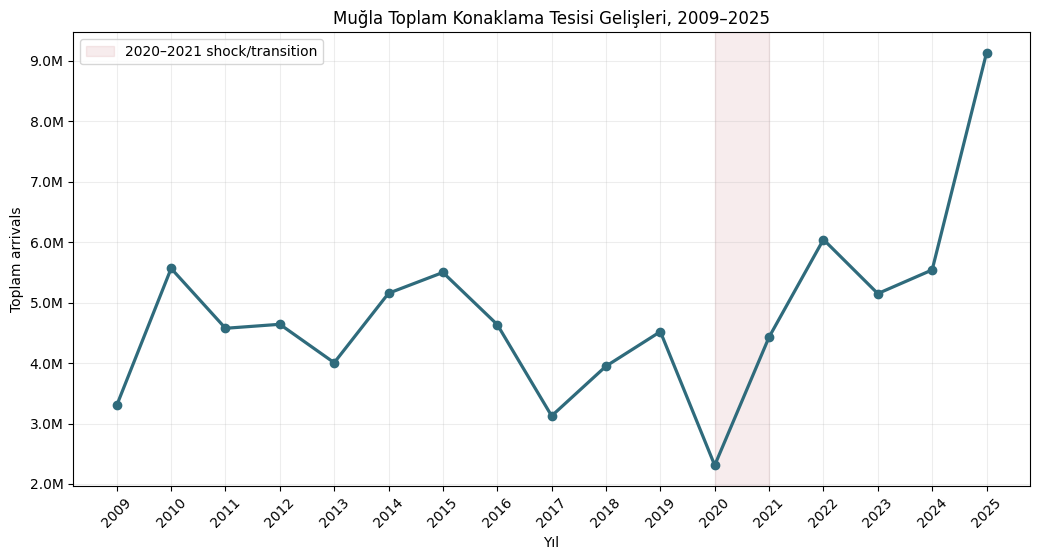

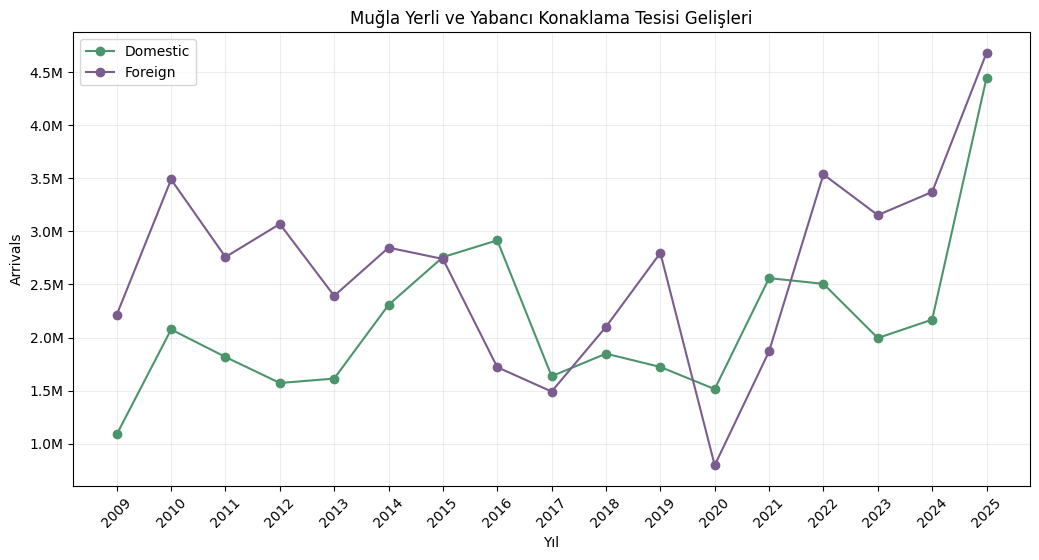

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/tourism_demand/02_domestic_vs_foreign_arrivals_2009_2025.png')

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 5.7))
ax.plot(annual_features["year"], annual_features["total_arrivals"], marker="o", color=PRIMARY, linewidth=2.3)
ax.axvspan(2020, 2021, color=ACCENT, alpha=0.12, label="2020–2021 shock/transition")
ax.set(title="Muğla Toplam Konaklama Tesisi Gelişleri, 2009–2025", xlabel="Yıl", ylabel="Toplam arrivals")
ax.set_xticks(annual_features["year"]); ax.tick_params(axis="x", rotation=45); ax.grid(alpha=0.22); millions_axis(ax); ax.legend()
save_fig(fig, "01_total_arrivals_2009_2025.png")

fig, ax = plt.subplots(figsize=(10.5, 5.7))
ax.plot(annual_features["year"], annual_features["domestic_arrivals"], marker="o", color=SECONDARY, label="Domestic")
ax.plot(annual_features["year"], annual_features["foreign_arrivals"], marker="o", color=PURPLE, label="Foreign")
ax.set(title="Muğla Yerli ve Yabancı Konaklama Tesisi Gelişleri", xlabel="Yıl", ylabel="Arrivals")
ax.set_xticks(annual_features["year"]); ax.tick_params(axis="x", rotation=45); ax.grid(alpha=0.22); millions_axis(ax); ax.legend()
save_fig(fig, "02_domestic_vs_foreign_arrivals_2009_2025.png")


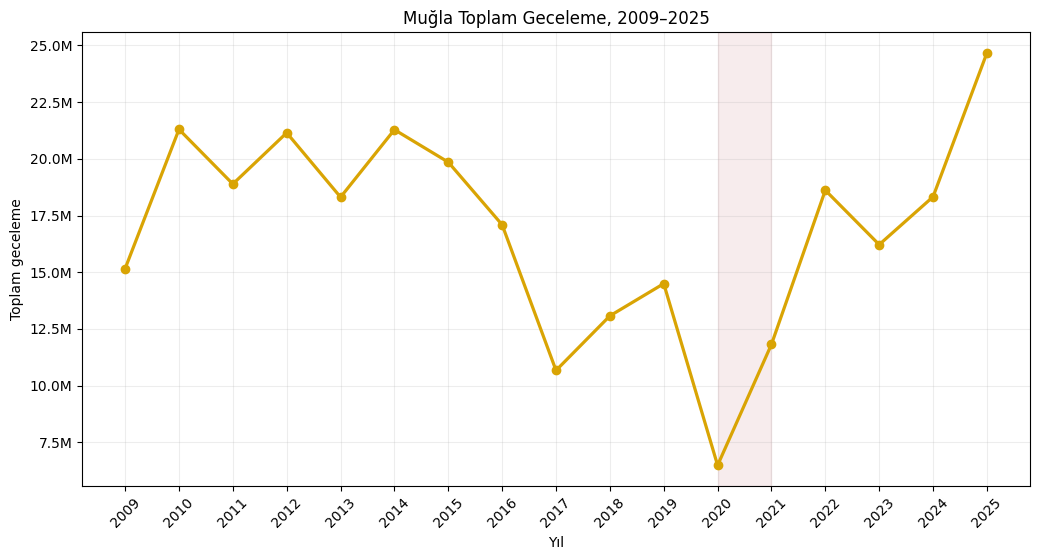

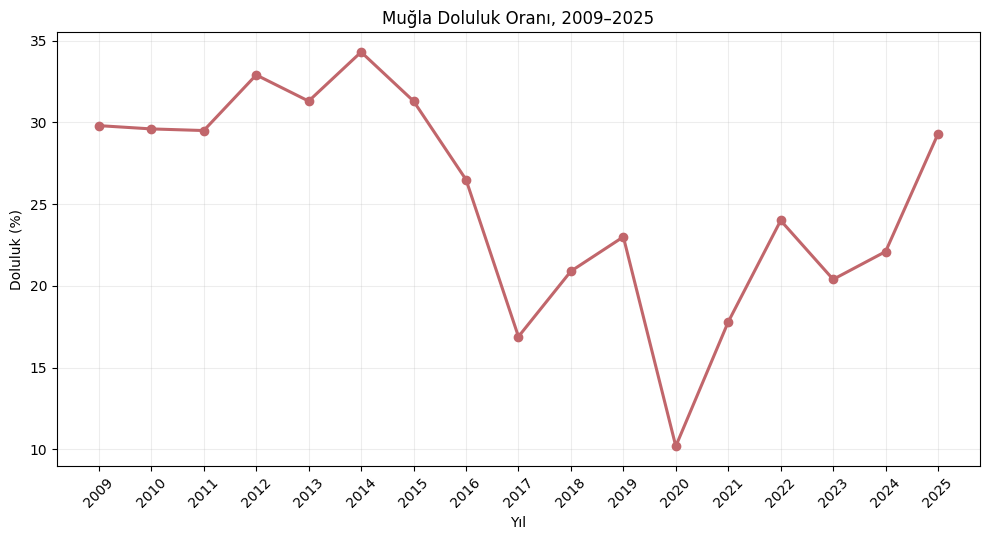

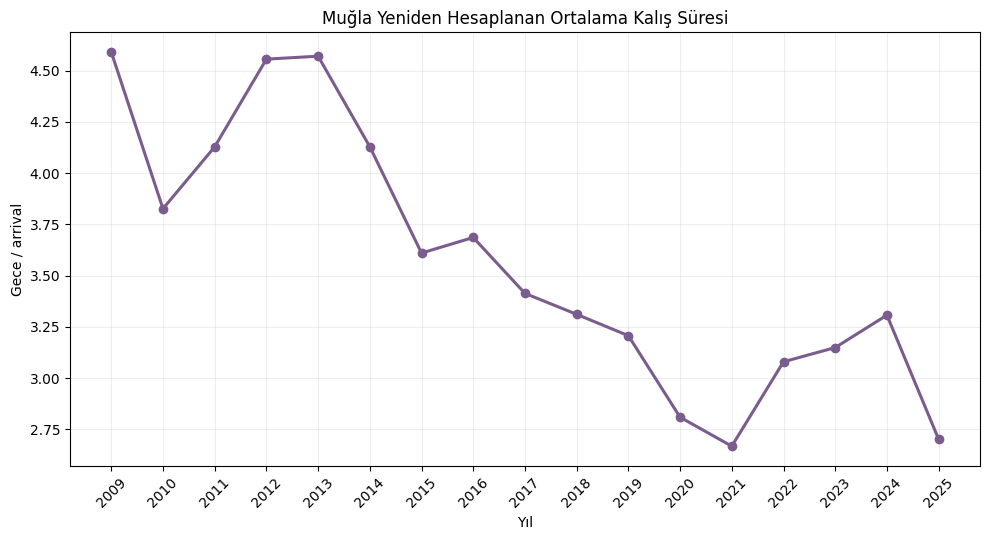

In [9]:
fig, ax = plt.subplots(figsize=(10.5, 5.7))
ax.plot(annual_features["year"], annual_features["total_overnights"], marker="o", color=HIGHLIGHT, linewidth=2.3)
ax.axvspan(2020, 2021, color=ACCENT, alpha=0.12)
ax.set(title="Muğla Toplam Geceleme, 2009–2025", xlabel="Yıl", ylabel="Toplam geceleme")
ax.set_xticks(annual_features["year"]); ax.tick_params(axis="x", rotation=45); ax.grid(alpha=0.22); millions_axis(ax)
save_fig(fig, "03_total_overnights_2009_2025.png")

line_chart(annual_features["year"], annual_features["occupancy_rate_pct"],
           "Muğla Doluluk Oranı, 2009–2025", "Doluluk (%)", "04_occupancy_rate_2009_2025.png", ACCENT)
line_chart(annual_features["year"], annual_features["derived_avg_stay_nights_recalculated"],
           "Muğla Yeniden Hesaplanan Ortalama Kalış Süresi", "Gece / arrival", "05_avg_stay_2009_2025.png", PURPLE)


### 5. Yıllık büyüme, en yüksek/düşük yıllar ve dönem özeti

In [10]:
growth_columns = [
    "year", "total_arrivals_yoy_pct", "domestic_arrivals_yoy_pct", "foreign_arrivals_yoy_pct",
    "total_overnights_yoy_pct", "occupancy_yoy_change_pp",
]
display(annual_features[growth_columns])

def metric_summary(frame, metric, period_col):
    series = frame[metric]
    return {
        "metric": metric, "n": series.count(), "mean": series.mean(), "median": series.median(),
        "minimum": series.min(), "minimum_period": frame.loc[series.idxmin(), period_col],
        "maximum": series.max(), "maximum_period": frame.loc[series.idxmax(), period_col],
    }

annual_metric_columns = [
    "domestic_arrivals", "foreign_arrivals", "total_arrivals", "total_overnights",
    "derived_avg_stay_nights_recalculated", "occupancy_rate_pct",
    "derived_foreign_arrival_share_pct_recalculated",
]
annual_summary = pd.DataFrame([metric_summary(annual_features, metric, "year") for metric in annual_metric_columns])
display(annual_summary)
period_comparison = period_summary(annual_features)
display(period_comparison)


,year,total_arrivals_yoy_pct,domestic_arrivals_yoy_pct,foreign_arrivals_yoy_pct,total_overnights_yoy_pct,occupancy_yoy_change_pp
0,2009,NaN,NaN,NaN,NaN,NaN
1,2010,68.5513,90.9860,57.5424,40.4911,-0.2000
2,2011,-17.7939,-12.4959,-20.9456,-11.3130,-0.1000
3,2012,1.4448,-13.5106,11.2924,11.9610,3.4000
4,2013,-13.6947,2.6666,-22.0671,-13.4220,-1.6000
5,2014,28.6900,43.0675,18.9978,16.2489,3.0000
6,2015,6.6699,19.5204,-3.7452,-6.7261,-3.0000
7,2016,-15.6866,5.7290,-37.2389,-13.9143,-4.8000
8,2017,-32.5787,-43.9282,-13.3369,-37.5636,-9.6000
9,2018,26.3263,13.0014,40.9426,22.5395,4.0000


,metric,n,mean,median,minimum,minimum_period,maximum,maximum_period
0,domestic_arrivals,17,"2,149,603.0588","1,995,354.0000","1,087,027.0000",2009,"4,447,019.0000",2025
1,foreign_arrivals,17,"2,649,289.7059","2,758,896.0000","795,698.0000",2020,"4,682,848.0000",2025
2,total_arrivals,17,"4,798,892.7647","4,636,526.0000","2,309,592.0000",2020,"9,129,867.0000",2025
3,total_overnights,17,"16,907,384.8824","18,310,720.0000","6,488,801.0000",2020,"24,669,490.0000",2025
4,derived_avg_stay_nights_recalculated,17,3.5734,3.4138,2.6681,2021,4.5911,2009
5,occupancy_rate_pct,17,25.2824,26.5000,10.2000,2020,34.3000,2014
6,derived_foreign_arrival_share_pct_recalculated,17,54.6780,58.5362,34.4519,2020,67.0820,2009


,analysis_period,year_count,start_year,end_year,average_annual_arrivals,average_foreign_share_pct,average_occupancy_pct,average_stay_nights
0,post_shock_2022_2025,4,2022,2025,"6,466,114.2500",57.9850,23.9500,3.0597
1,pre_pandemic_2009_2019,11,2009,2019,"4,452,486.0909",56.4473,27.8182,3.9120
2,shock_transition_2020_2021,2,2020,2021,"3,369,686.5000",38.3300,14.0000,2.7388


In [11]:
extremes = annual_summary[["metric", "minimum", "minimum_period", "maximum", "maximum_period"]]
display(extremes)
display(Markdown(
    f"**Bulgu:** En yüksek toplam arrivals {int(extremes.loc[extremes.metric.eq('total_arrivals'), 'maximum_period'].iloc[0])}, "
    f"en düşük toplam arrivals {int(extremes.loc[extremes.metric.eq('total_arrivals'), 'minimum_period'].iloc[0])} yılında. "
    f"2020, pandemi dönemiyle örtüşen belirgin kırılma yılıdır; bu ifade yalnız zamansal örtüşmeyi "
    f"tanımlar, saf nedensel etki tahmini değildir."
))


,metric,minimum,minimum_period,maximum,maximum_period
0,domestic_arrivals,"1,087,027.0000",2009,"4,447,019.0000",2025
1,foreign_arrivals,"795,698.0000",2020,"4,682,848.0000",2025
2,total_arrivals,"2,309,592.0000",2020,"9,129,867.0000",2025
3,total_overnights,"6,488,801.0000",2020,"24,669,490.0000",2025
4,derived_avg_stay_nights_recalculated,2.6681,2021,4.5911,2009
5,occupancy_rate_pct,10.2000,2020,34.3000,2014
6,derived_foreign_arrival_share_pct_recalculated,34.4519,2020,67.0820,2009


**Bulgu:** En yüksek toplam arrivals 2025, en düşük toplam arrivals 2020 yılında. 2020, pandemi dönemiyle örtüşen belirgin kırılma yılıdır; bu ifade yalnız zamansal örtüşmeyi tanımlar, saf nedensel etki tahmini değildir.

### 6. 2019 benchmark, 2020 kırılması ve 2022–2025 toparlanma

In [12]:
recovery = annual_features.loc[annual_features["year"].between(2019, 2025), [
    "year", "total_arrivals", "total_arrivals_vs_2019_pct", "foreign_arrivals_vs_2019_pct",
    "domestic_arrivals_vs_2019_pct", "overnights_vs_2019_pct", "occupancy_vs_2019_pp",
]]
display(recovery)

row_2020 = annual_features.set_index("year").loc[2020]
row_2025 = annual_features.set_index("year").loc[2025]
display(Markdown(
    f"**Bulgu:** 2020'de toplam arrivals 2019'a göre %{row_2020.total_arrivals_vs_2019_pct:.1f}, "
    f"foreign arrivals %{row_2020.foreign_arrivals_vs_2019_pct:.1f}, overnights %{row_2020.overnights_vs_2019_pct:.1f}; "
    f"occupancy {row_2020.occupancy_vs_2019_pp:.1f} yüzde puan değişmiştir. 2025 toplam arrivals "
    f"2019'un %{row_2025.total_arrivals_vs_2019_pct:.1f} üzerindedir. Dönem karşılaştırmalarında "
    f"2009–2019 (11 yıl) ve 2022–2025 (4 yıl) uzunlukları farklıdır."
))


,year,total_arrivals,total_arrivals_vs_2019_pct,foreign_arrivals_vs_2019_pct,domestic_arrivals_vs_2019_pct,overnights_vs_2019_pct,occupancy_vs_2019_pp
10,2019,4520044,0.0000,0.0000,0.0000,0.0000,0.0000
11,2020,2309592,-48.9033,-71.5571,-12.1115,-55.2411,-12.8000
12,2021,4429781,-1.9969,-33.1618,48.6178,-18.4723,-5.2000
13,2022,6043972,33.7149,26.4656,45.4884,28.4068,1.0000
14,2023,5149488,13.9256,12.7472,15.8395,11.8665,-2.6000
15,2024,5541130,22.5902,20.5473,25.9080,26.4185,-0.9000
16,2025,9129867,101.9862,67.3924,158.1700,70.1670,6.3000


**Bulgu:** 2020'de toplam arrivals 2019'a göre %-48.9, foreign arrivals %-71.6, overnights %-55.2; occupancy -12.8 yüzde puan değişmiştir. 2025 toplam arrivals 2019'un %102.0 üzerindedir. Dönem karşılaştırmalarında 2009–2019 (11 yıl) ve 2022–2025 (4 yıl) uzunlukları farklıdır.

### 7. Muğla 2025 aylık sezonluk talep

Aşağıdaki tüm aylık grafikler **Muğla ili** içindir; Bodrum ilçesi aylık serisi değildir. Aylar
`PeriodIndex` ve açık Türkçe ay sırası ile kronolojik tutulur.


,period,month_name_tr,domestic_arrivals,foreign_arrivals,total_arrivals,total_overnights,occupancy_rate_pct,derived_avg_stay_nights_recalculated,derived_foreign_arrival_share_pct_recalculated,monthly_arrival_share_pct,monthly_overnight_share_pct,season_group
0,2025-01,Ocak,64542,3844,68386,142502,2.0000,2.0838,5.6210,0.7490,0.5776,LOW
1,2025-02,Şubat,48810,2953,51763,105629,1.7000,2.0406,5.7048,0.5670,0.4282,LOW
2,2025-03,Mart,60579,18837,79416,179197,2.5000,2.2564,23.7194,0.8698,0.7264,LOW
3,2025-04,Nisan,116579,199073,315652,907810,13.3000,2.8760,63.0672,3.4574,3.6799,SHOULDER
4,2025-05,Mayıs,190473,409930,600403,1861071,26.5000,3.0997,68.2758,6.5763,7.5440,SHOULDER
5,2025-06,Haziran,327234,506596,833830,2620230,38.5000,3.1424,60.7553,9.1330,10.6213,SHOULDER
6,2025-07,Temmuz,981859,828261,1810120,4906797,70.0000,2.7108,45.7572,19.8264,19.8901,PEAK
7,2025-08,Ağustos,1061003,942171,2003174,5317523,75.8000,2.6545,47.0339,21.9409,21.5551,PEAK
8,2025-09,Eylül,695523,931353,1626876,4365162,64.2000,2.6832,57.2479,17.8193,17.6946,PEAK
9,2025-10,Ekim,380029,748759,1128788,2988039,42.5000,2.6471,66.3330,12.3637,12.1123,PEAK


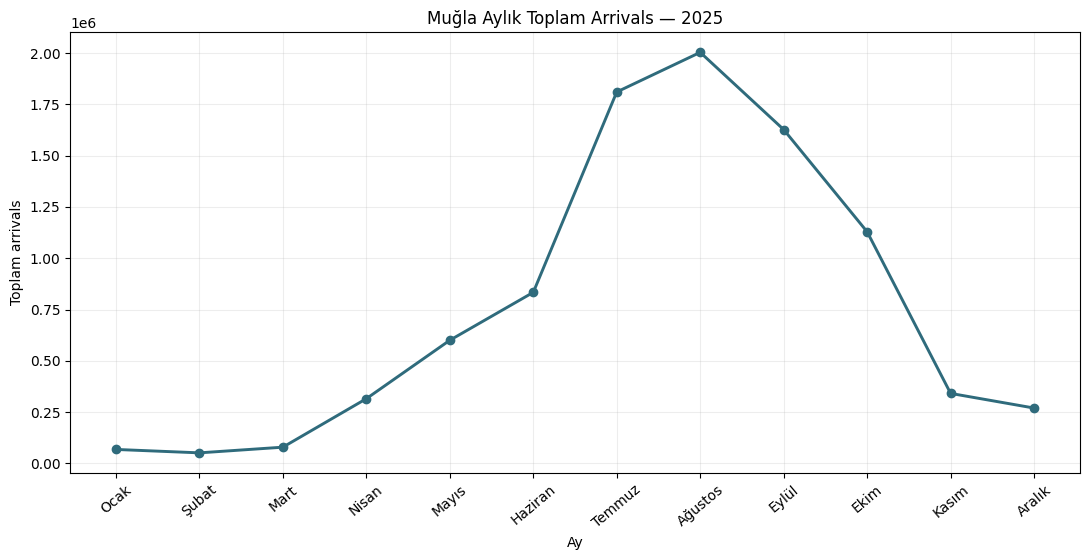

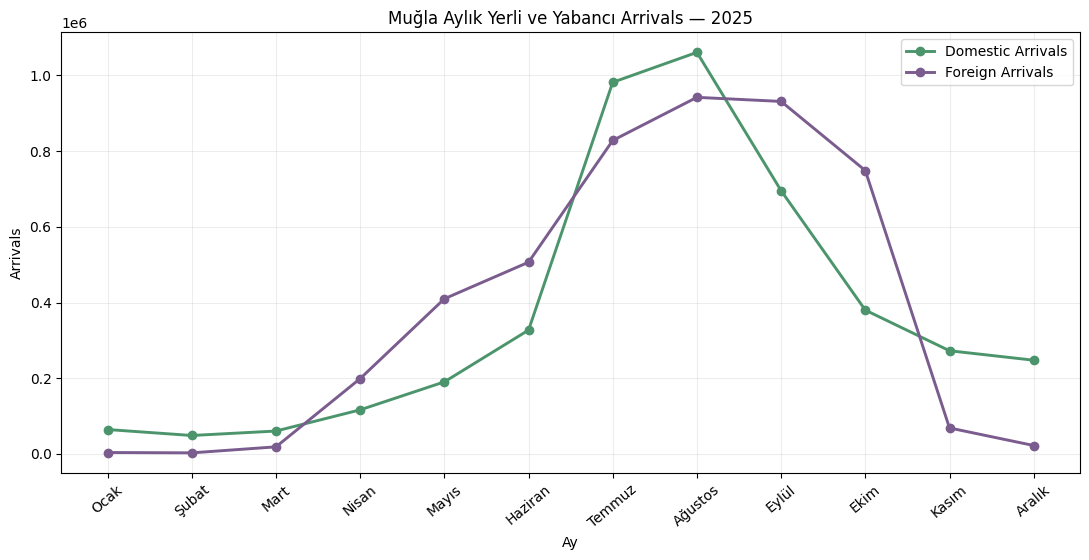

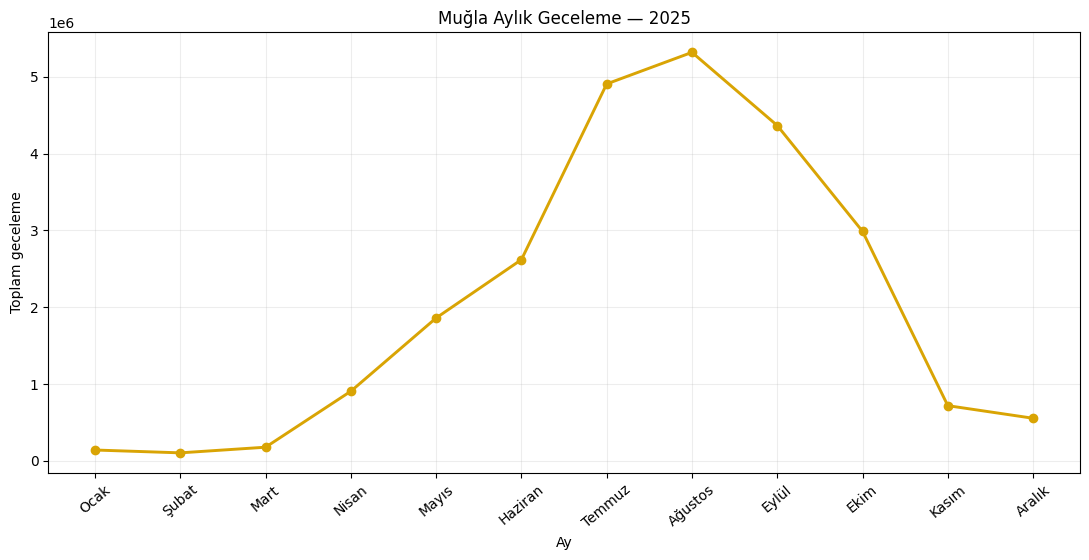

In [13]:
monthly_core = monthly_features[[
    "period", "month_name_tr", "domestic_arrivals", "foreign_arrivals", "total_arrivals",
    "total_overnights", "occupancy_rate_pct", "derived_avg_stay_nights_recalculated",
    "derived_foreign_arrival_share_pct_recalculated", "monthly_arrival_share_pct",
    "monthly_overnight_share_pct", "season_group",
]]
display(monthly_core)

monthly_chart(monthly_features, ["total_arrivals"], "Muğla Aylık Toplam Arrivals — 2025",
              "Toplam arrivals", "06_monthly_total_arrivals_2025.png", [PRIMARY])
monthly_chart(monthly_features, ["domestic_arrivals", "foreign_arrivals"],
              "Muğla Aylık Yerli ve Yabancı Arrivals — 2025", "Arrivals",
              "07_monthly_domestic_foreign_2025.png", [SECONDARY, PURPLE])
monthly_chart(monthly_features, ["total_overnights"], "Muğla Aylık Geceleme — 2025",
              "Toplam geceleme", "08_monthly_overnights_2025.png", [HIGHLIGHT])


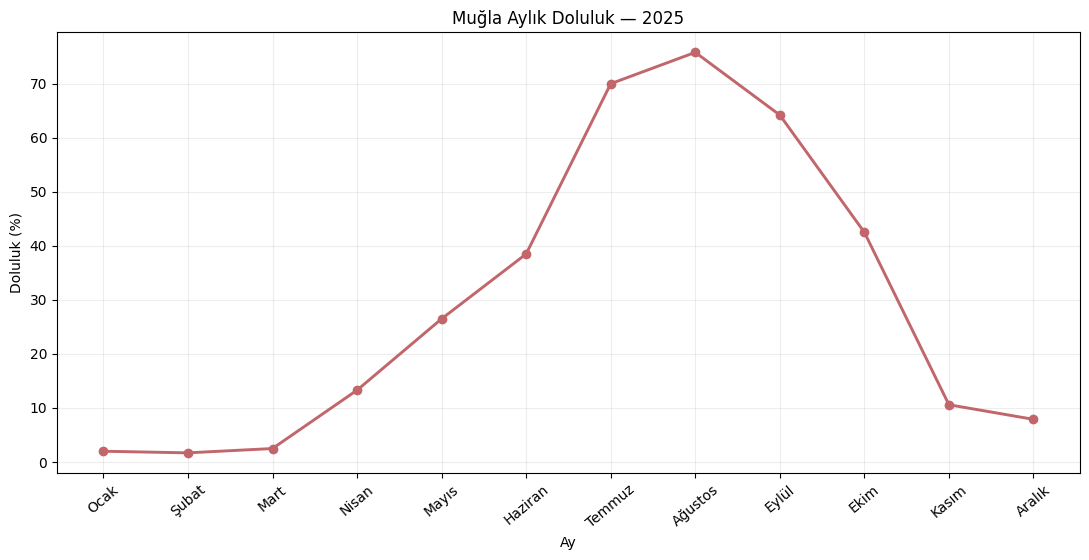

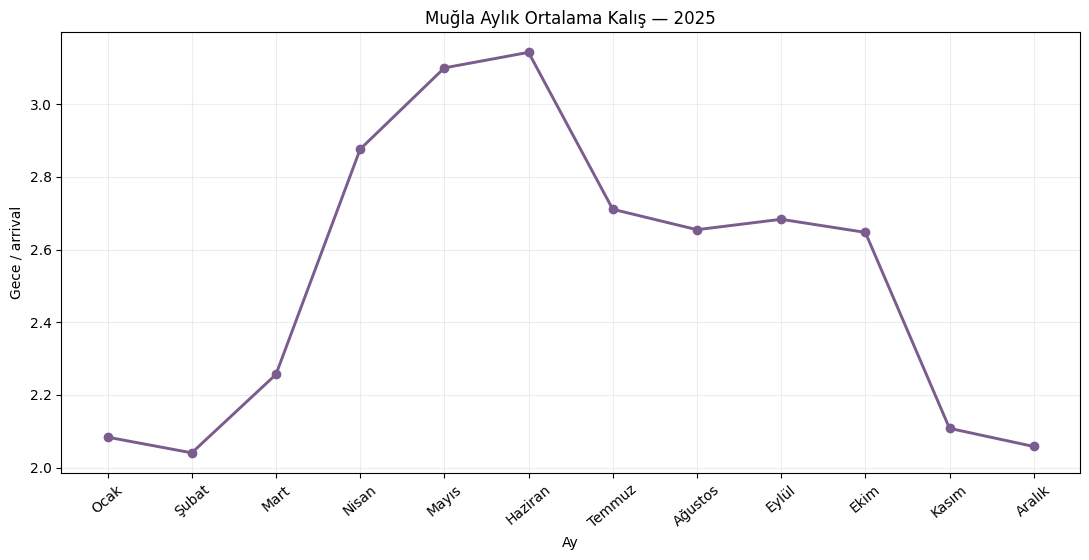

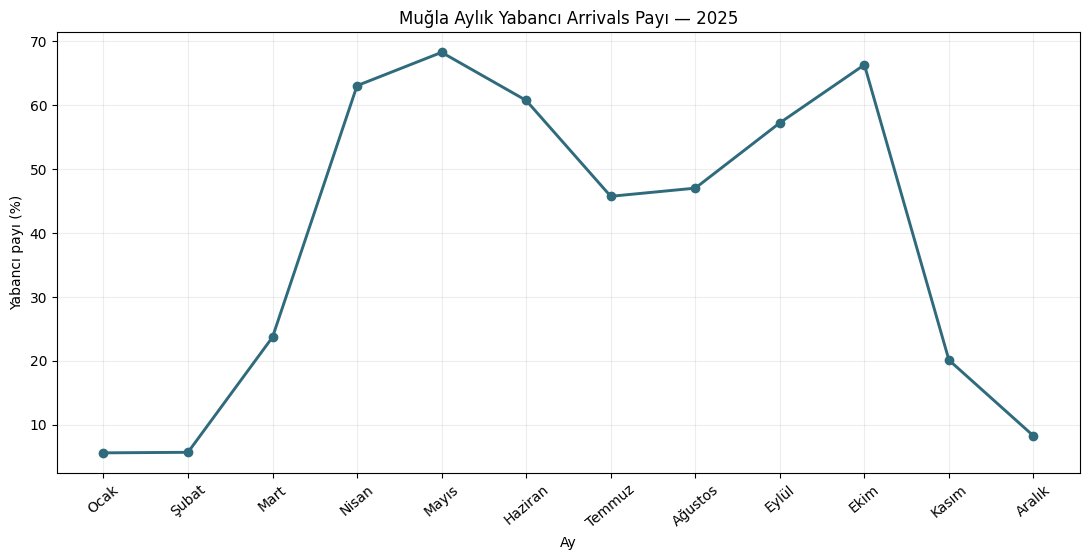

In [14]:
monthly_chart(monthly_features, ["occupancy_rate_pct"], "Muğla Aylık Doluluk — 2025",
              "Doluluk (%)", "09_monthly_occupancy_2025.png", [ACCENT])
monthly_chart(monthly_features, ["derived_avg_stay_nights_recalculated"],
              "Muğla Aylık Ortalama Kalış — 2025", "Gece / arrival",
              "10_monthly_average_stay_2025.png", [PURPLE])
monthly_chart(monthly_features, ["derived_foreign_arrival_share_pct_recalculated"],
              "Muğla Aylık Yabancı Arrivals Payı — 2025", "Yabancı payı (%)",
              "11_monthly_foreign_share_2025.png", [PRIMARY])


### 8. Aylık yıllık pay, peak aylar ve sezon yoğunlaşması

In [15]:
peak_metrics = {
    "peak_arrival_month": monthly_features.loc[monthly_features["total_arrivals"].idxmax(), "month_name_tr"],
    "peak_foreign_arrival_month": monthly_features.loc[monthly_features["foreign_arrivals"].idxmax(), "month_name_tr"],
    "peak_domestic_arrival_month": monthly_features.loc[monthly_features["domestic_arrivals"].idxmax(), "month_name_tr"],
    "peak_overnight_month": monthly_features.loc[monthly_features["total_overnights"].idxmax(), "month_name_tr"],
    "peak_occupancy_month": monthly_features.loc[monthly_features["occupancy_rate_pct"].idxmax(), "month_name_tr"],
    "peak_average_stay_month": monthly_features.loc[monthly_features["derived_avg_stay_nights_recalculated"].idxmax(), "month_name_tr"],
    "peak_foreign_share_month": monthly_features.loc[monthly_features["derived_foreign_arrival_share_pct_recalculated"].idxmax(), "month_name_tr"],
    "lowest_arrival_month": monthly_features.loc[monthly_features["total_arrivals"].idxmin(), "month_name_tr"],
    "lowest_occupancy_month": monthly_features.loc[monthly_features["occupancy_rate_pct"].idxmin(), "month_name_tr"],
}
display(pd.DataFrame([peak_metrics]))
seasonality = seasonality_metrics(monthly_features)
display(seasonality)


,peak_arrival_month,peak_foreign_arrival_month,peak_domestic_arrival_month,peak_overnight_month,peak_occupancy_month,peak_average_stay_month,peak_foreign_share_month,lowest_arrival_month,lowest_occupancy_month
0,Ağustos,Ağustos,Ağustos,Ağustos,Ağustos,Haziran,Mayıs,Şubat,Şubat


,geography,year,monthly_observation_n,peak_to_low_arrival_ratio,peak_to_low_overnight_ratio,top3_month_arrival_share_pct,top3_month_overnight_share_pct,top4_month_arrival_share_pct,coefficient_of_variation_arrivals,coefficient_of_variation_overnights,coefficient_of_variation_occupancy,hhi_monthly_arrival_concentration,hhi_monthly_overnight_concentration
0,Muğla,2025,12,38.6990,50.3415,59.5865,59.1398,71.9502,0.9397,0.9467,0.9433,0.1508,0.1518


In [16]:
display(Markdown(
    f"**Bulgu:** Peak toplam arrivals, foreign arrivals, domestic arrivals, geceleme ve doluluk ayı "
    f"{peak_metrics['peak_arrival_month']}. En yüksek yabancı payı {peak_metrics['peak_foreign_share_month']}; "
    f"en yüksek ortalama kalış {peak_metrics['peak_average_stay_month']} ayındadır. Top 3 ay toplam "
    f"arrivals'ın %{seasonality.iloc[0]['top3_month_arrival_share_pct']:.1f}'ini oluşturur. Aylık arrivals "
    f"HHI={seasonality.iloc[0]['hhi_monthly_arrival_concentration']:.3f}; bu yalnız yıl içi yoğunlaşma "
    f"göstergesidir, iyi/kötü hükmü değildir."
))


**Bulgu:** Peak toplam arrivals, foreign arrivals, domestic arrivals, geceleme ve doluluk ayı Ağustos. En yüksek yabancı payı Mayıs; en yüksek ortalama kalış Haziran ayındadır. Top 3 ay toplam arrivals'ın %59.6'ini oluşturur. Aylık arrivals HHI=0.151; bu yalnız yıl içi yoğunlaşma göstergesidir, iyi/kötü hükmü değildir.

### 9. Percentile tabanlı PEAK / SHOULDER / LOW sezon grupları

In [17]:
display(pd.DataFrame([{
    "method": "total arrivals tertile thresholds",
    "low_upper_q33": monthly_metadata["season_q33_total_arrivals"],
    "shoulder_upper_q67": monthly_metadata["season_q67_total_arrivals"],
    "rule": "<q33 LOW; q33–q67 SHOULDER; >=q67 PEAK",
}]))
display(monthly_features[["period", "month_name_tr", "total_arrivals", "season_group"]])
season_groups = season_group_summary(monthly_features)
display(season_groups)


,method,low_upper_q33,shoulder_upper_q67,rule
0,total arrivals tertile thresholds,"300,451.0000","932,149.3333",<q33 LOW; q33–q67 SHOULDER; >=q67 PEAK


,period,month_name_tr,total_arrivals,season_group
0,2025-01,Ocak,68386,LOW
1,2025-02,Şubat,51763,LOW
2,2025-03,Mart,79416,LOW
3,2025-04,Nisan,315652,SHOULDER
4,2025-05,Mayıs,600403,SHOULDER
5,2025-06,Haziran,833830,SHOULDER
6,2025-07,Temmuz,1810120,PEAK
7,2025-08,Ağustos,2003174,PEAK
8,2025-09,Eylül,1626876,PEAK
9,2025-10,Ekim,1128788,PEAK


,season_group,month_count,avg_total_arrivals,avg_foreign_arrivals,avg_domestic_arrivals,avg_overnights,avg_occupancy,avg_stay,foreign_share_pct
0,LOW,4,"117,403.5000","11,993.5000","105,410.0000","245,781.2500",3.5250,2.1097,10.2156
1,PEAK,4,"1,642,239.5000","862,636.0000","779,603.5000","4,394,380.2500",63.1250,2.6739,52.5280
2,SHOULDER,4,"522,823.7500","296,082.5000","226,741.2500","1,527,211.0000",22.2250,2.8066,56.6314


### 10. Yerli ve yabancı sezon şekli

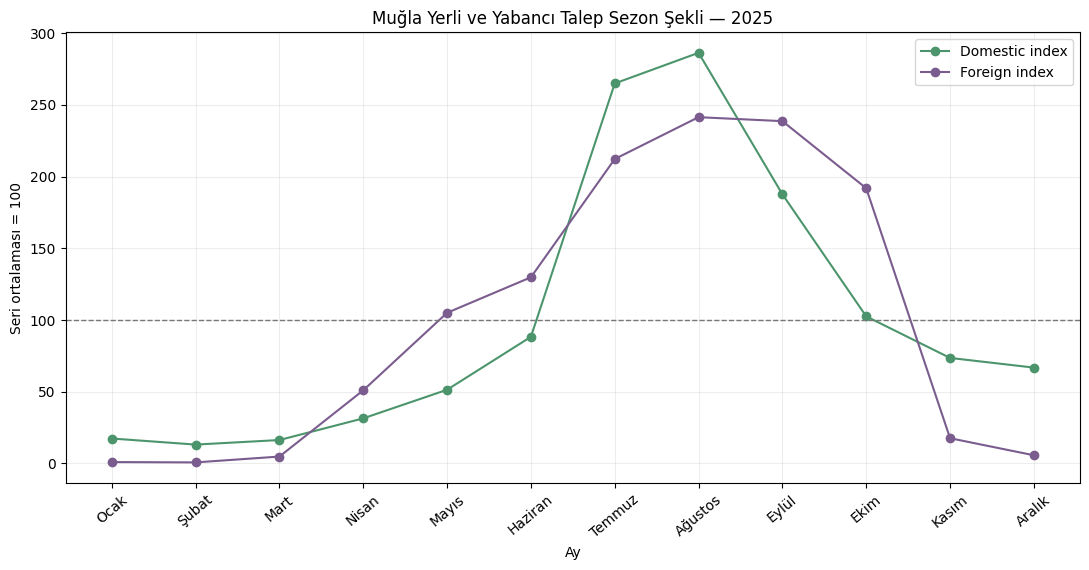

**Bulgu:** Yerli ve yabancı aylık seri şekilleri güçlü biçimde birlikte hareket eder (Spearman ρ=0.93, n=12), ancak foreign-share zirvesi ile toplam arrivals zirvesi aynı ay olmak zorunda değildir.

In [18]:
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.plot(monthly_features["month_name_tr"].astype(str), monthly_features["domestic_seasonality_index"],
        marker="o", color=SECONDARY, label="Domestic index")
ax.plot(monthly_features["month_name_tr"].astype(str), monthly_features["foreign_seasonality_index"],
        marker="o", color=PURPLE, label="Foreign index")
ax.axhline(100, color=NEUTRAL, linestyle="--", linewidth=1)
ax.set(title="Muğla Yerli ve Yabancı Talep Sezon Şekli — 2025", xlabel="Ay", ylabel="Seri ortalaması = 100")
ax.tick_params(axis="x", rotation=40); ax.grid(alpha=0.22); ax.legend()
save_fig(fig, "12_domestic_foreign_seasonality_index.png")

domestic_foreign_rho = monthly_features["domestic_arrivals"].corr(
    monthly_features["foreign_arrivals"], method="spearman"
)
display(Markdown(
    f"**Bulgu:** Yerli ve yabancı aylık seri şekilleri güçlü biçimde birlikte hareket eder "
    f"(Spearman ρ={domestic_foreign_rho:.2f}, n=12), ancak foreign-share zirvesi ile toplam arrivals "
    f"zirvesi aynı ay olmak zorunda değildir."
))


### 11. Arrivals, kalış süresi ve doluluk ilişkileri

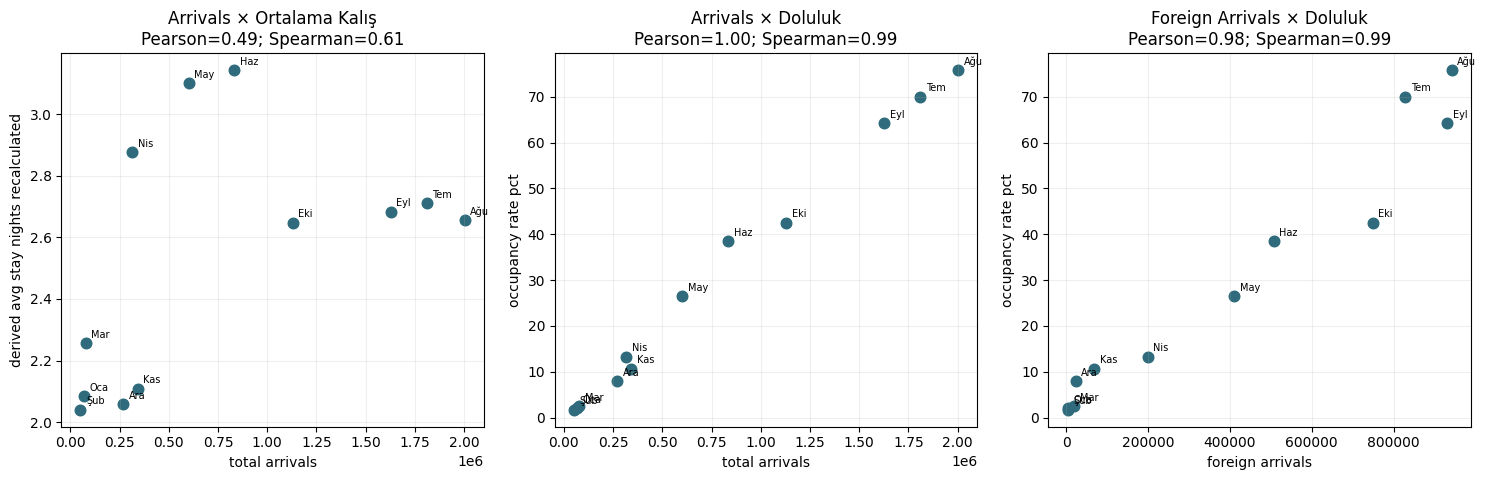

,metric_x,metric_y,n,pearson,spearman
0,total_arrivals,derived_avg_stay_nights_recalculated,12,0.4911,0.6084
1,total_arrivals,occupancy_rate_pct,12,0.9959,0.9930
2,foreign_arrivals,occupancy_rate_pct,12,0.9782,0.9930


In [19]:
monthly_relationships = [
    ("total_arrivals", "derived_avg_stay_nights_recalculated", "Arrivals × Ortalama Kalış"),
    ("total_arrivals", "occupancy_rate_pct", "Arrivals × Doluluk"),
    ("foreign_arrivals", "occupancy_rate_pct", "Foreign Arrivals × Doluluk"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.9))
relationship_rows = []
for ax, (x, y, title) in zip(axes, monthly_relationships):
    ax.scatter(monthly_features[x], monthly_features[y], color=PRIMARY, s=58)
    for row in monthly_features.itertuples():
        ax.annotate(str(row.month_name_tr)[:3], (getattr(row, x), getattr(row, y)), xytext=(4, 4),
                    textcoords="offset points", fontsize=7)
    pearson = monthly_features[x].corr(monthly_features[y], method="pearson")
    spearman = monthly_features[x].corr(monthly_features[y], method="spearman")
    relationship_rows.append({"metric_x": x, "metric_y": y, "n": 12, "pearson": pearson, "spearman": spearman})
    ax.set(title=f"{title}\nPearson={pearson:.2f}; Spearman={spearman:.2f}", xlabel=x.replace("_", " "), ylabel=y.replace("_", " "))
    ax.grid(alpha=0.2)
save_fig(fig, "13_monthly_relationships_2025.png")
display(pd.DataFrame(relationship_rows))


In [20]:
display(Markdown(
    "**Sınırlılık:** Arrivals ve occupancy aynı kavram değildir. Doluluk; açık tesis/oda-yatak arzı, "
    "kapasite kullanılabilirliği ve tesislerin sezonluk çalışma düzeninden etkilenebilir. n=12 "
    "korelasyonları yalnız keşifseldir."
))


**Sınırlılık:** Arrivals ve occupancy aynı kavram değildir. Doluluk; açık tesis/oda-yatak arzı, kapasite kullanılabilirliği ve tesislerin sezonluk çalışma düzeninden etkilenebilir. n=12 korelasyonları yalnız keşifseldir.

### 12. Bodrum 2025 yıllık profili

In [21]:
bodrum_profile_columns = [
    "year", "geography", "geography_level", "domestic_arrivals", "foreign_arrivals",
    "total_arrivals", "total_overnights", "domestic_share_pct", "foreign_share_pct",
    "avg_stay_nights_recalculated",
]
display(bodrum_2025[bodrum_profile_columns])


,year,geography,geography_level,domestic_arrivals,foreign_arrivals,total_arrivals,total_overnights,domestic_share_pct,foreign_share_pct,avg_stay_nights_recalculated
0,2025,Bodrum,district,1624032,1199393,2823425,7579360,57.5199,42.4801,2.6845


### 13. Bodrum vs Muğla 2025 — ortak yıllık konaklama istatistiği kapsamı

In [22]:
core_definition_columns = set(CORE_FLOW_COLUMNS)
assert core_definition_columns.issubset(bodrum_raw.columns)
assert core_definition_columns.issubset(annual_raw.columns)
assert "Kültür ve Turizm Bakanlığı" in bodrum_raw["source_origin"].iloc[0]
assert "Kültür ve Turizm Bakanlığı" in annual_raw["source_origin"].iloc[0]

bodrum_vs_mugla = bodrum_vs_mugla_profile(bodrum_2025, mugla_2025)
display(bodrum_vs_mugla)


,year,definition_comparable,comparison_scope_note,bodrum_domestic_arrivals,mugla_domestic_arrivals,bodrum_share_of_mugla_domestic_arrivals_pct,bodrum_foreign_arrivals,mugla_foreign_arrivals,bodrum_share_of_mugla_foreign_arrivals_pct,bodrum_total_arrivals,mugla_total_arrivals,bodrum_share_of_mugla_total_arrivals_pct,bodrum_total_overnights,mugla_total_overnights,bodrum_share_of_mugla_total_overnights_pct,bodrum_domestic_share_pct,mugla_domestic_share_pct,bodrum_foreign_share_pct,mugla_foreign_share_pct,bodrum_avg_stay_nights,mugla_avg_stay_nights
0,2025,True,Shared official accommodation-statistics scope; district versus province.,1624032,4447019,36.5196,1199393,4682848,25.6125,2823425,9129867,30.9251,7579360,24669490,30.7236,57.5199,48.7085,42.4801,51.2915,2.6845,2.7021


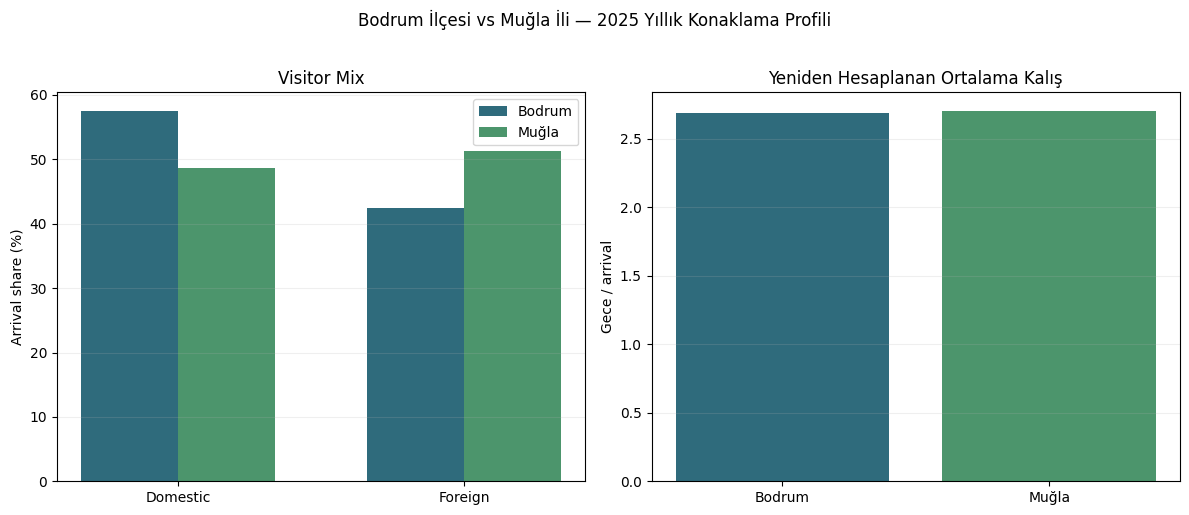

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/tourism_demand/14_bodrum_vs_mugla_visitor_mix_2025.png')

In [23]:
mix_metrics = ["Domestic share (%)", "Foreign share (%)", "Avg stay (nights)"]
bodrum_mix = [
    bodrum_vs_mugla.loc[0, "bodrum_domestic_share_pct"],
    bodrum_vs_mugla.loc[0, "bodrum_foreign_share_pct"],
    bodrum_vs_mugla.loc[0, "bodrum_avg_stay_nights"],
]
mugla_mix = [
    bodrum_vs_mugla.loc[0, "mugla_domestic_share_pct"],
    bodrum_vs_mugla.loc[0, "mugla_foreign_share_pct"],
    bodrum_vs_mugla.loc[0, "mugla_avg_stay_nights"],
]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(2); width = 0.34
axes[0].bar(x - width/2, bodrum_mix[:2], width, label="Bodrum", color=PRIMARY)
axes[0].bar(x + width/2, mugla_mix[:2], width, label="Muğla", color=SECONDARY)
axes[0].set_xticks(x, ["Domestic", "Foreign"]); axes[0].set_ylabel("Arrival share (%)")
axes[0].set_title("Visitor Mix"); axes[0].legend(); axes[0].grid(axis="y", alpha=0.2)
axes[1].bar(["Bodrum", "Muğla"], [bodrum_mix[2], mugla_mix[2]], color=[PRIMARY, SECONDARY])
axes[1].set_ylabel("Gece / arrival"); axes[1].set_title("Yeniden Hesaplanan Ortalama Kalış")
axes[1].grid(axis="y", alpha=0.2)
fig.suptitle("Bodrum İlçesi vs Muğla İli — 2025 Yıllık Konaklama Profili", y=1.02)
save_fig(fig, "14_bodrum_vs_mugla_visitor_mix_2025.png")


In [24]:
bodrum_total_share = bodrum_vs_mugla.loc[0, "bodrum_share_of_mugla_total_arrivals_pct"]
display(Markdown(
    f"**Bulgu:** Ortak resmî konaklama istatistiği kapsamı içinde Bodrum'un Muğla toplam 2025 "
    f"arrivals payı %{bodrum_total_share:.1f}; foreign arrivals payı "
    f"%{bodrum_vs_mugla.loc[0, 'bodrum_share_of_mugla_foreign_arrivals_pct']:.1f}; domestic arrivals "
    f"payı %{bodrum_vs_mugla.loc[0, 'bodrum_share_of_mugla_domestic_arrivals_pct']:.1f}'dir. "
    f"Bodrum'un domestic mix payı %{bodrum_vs_mugla.loc[0, 'bodrum_domestic_share_pct']:.1f}, "
    f"Muğla'nın %{bodrum_vs_mugla.loc[0, 'mugla_domestic_share_pct']:.1f}'dir."
))


**Bulgu:** Ortak resmî konaklama istatistiği kapsamı içinde Bodrum'un Muğla toplam 2025 arrivals payı %30.9; foreign arrivals payı %25.6; domestic arrivals payı %36.5'dir. Bodrum'un domestic mix payı %57.5, Muğla'nın %48.7'dir.

### 14. Destination Intelligence ile yalnız bağlamsal ilişki

In [25]:
if destination_context is not None:
    destination_layer_context = pd.DataFrame([{
        "hotel_snapshot_scope": "14 Bodrum destinations, 2026-08-24 Google/hotel snapshot",
        "sample_hotel_count": int(destination_context["sample_hotel_count"].sum()),
        "high_confidence_matched_hotels": int(destination_context["official_matched_hotel_count"].sum()),
        "matched_official_rooms": destination_context["total_official_rooms"].sum(min_count=1),
        "tourism_demand_scope": "Bodrum district annual 2025; Muğla province monthly/annual 2025",
        "grain_join_performed": False,
        "time_scope_warning": "Hotel snapshot is 2026; tourism demand is 2025.",
    }])
    display(destination_layer_context)


,hotel_snapshot_scope,sample_hotel_count,high_confidence_matched_hotels,matched_official_rooms,tourism_demand_scope,grain_join_performed,time_scope_warning
0,"14 Bodrum destinations, 2026-08-24 Google/hotel snapshot",192,52,"6,248.0000",Bodrum district annual 2025; Muğla province monthly/annual 2025,False,Hotel snapshot is 2026; tourism demand is 2025.


14 destinasyon otel metrikleri Muğla aylık talebiyle join edilmemiştir. Destinasyon bazlı aylık
talep bulunmadığından “Yalıkavak Temmuz talebi” veya “Gümbet Ağustos doluluğu” üretilemez. Hotel
snapshot'ı 2026, turizm talebi 2025 olduğundan çapraz katman yorumları zaman farkı taşır.


### 15. Muğla 2025 aylık korelasyon tablosu

,metric_x,metric_y,method,n,coefficient,p_value,interpretation_note
0,domestic_arrivals,foreign_arrivals,pearson,12,0.8671,0.0003,"Exploratory monthly association; n=12, correlation is not causation."
1,domestic_arrivals,foreign_arrivals,spearman,12,0.9301,0.0000,"Exploratory monthly association; n=12, correlation is not causation."
2,domestic_arrivals,total_arrivals,pearson,12,0.9630,0.0000,"Exploratory monthly association; n=12, correlation is not causation."
3,domestic_arrivals,total_arrivals,spearman,12,0.9580,0.0000,"Exploratory monthly association; n=12, correlation is not causation."
4,domestic_arrivals,total_overnights,pearson,12,0.9475,0.0000,"Exploratory monthly association; n=12, correlation is not causation."
5,domestic_arrivals,total_overnights,spearman,12,0.9371,0.0000,"Exploratory monthly association; n=12, correlation is not causation."
6,domestic_arrivals,occupancy_rate_pct,pearson,12,0.9449,0.0000,"Exploratory monthly association; n=12, correlation is not causation."
7,domestic_arrivals,occupancy_rate_pct,spearman,12,0.9371,0.0000,"Exploratory monthly association; n=12, correlation is not causation."
8,domestic_arrivals,derived_avg_stay_nights_recalculated,pearson,12,0.3218,0.3078,"Exploratory monthly association; n=12, correlation is not causation."
9,domestic_arrivals,derived_avg_stay_nights_recalculated,spearman,12,0.4266,0.1667,"Exploratory monthly association; n=12, correlation is not causation."


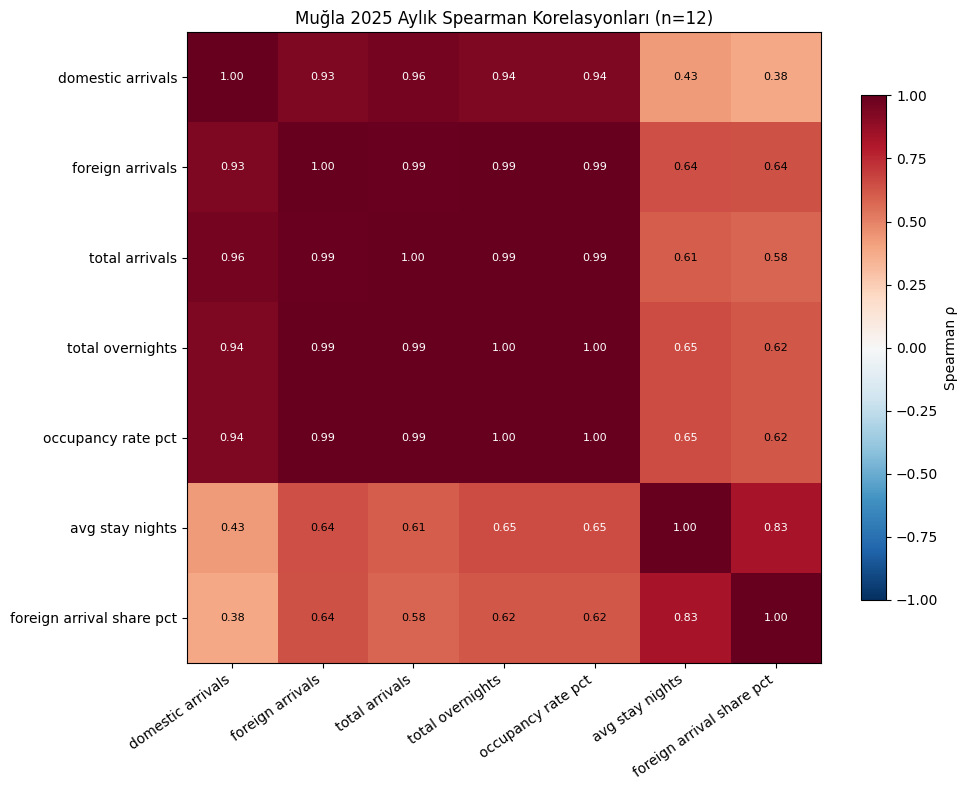

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/tourism_demand/15_monthly_correlation_heatmap_2025.png')

In [26]:
correlation_columns = [
    "domestic_arrivals", "foreign_arrivals", "total_arrivals", "total_overnights",
    "occupancy_rate_pct", "derived_avg_stay_nights_recalculated",
    "derived_foreign_arrival_share_pct_recalculated",
]
correlations = monthly_correlations(monthly_features, correlation_columns)
display(correlations)

spearman_matrix = monthly_features[correlation_columns].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(spearman_matrix.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
labels = [c.replace("derived_", "").replace("_recalculated", "").replace("_", " ") for c in correlation_columns]
ax.set_xticks(range(len(labels)), labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_title("Muğla 2025 Aylık Spearman Korelasyonları (n=12)")
for i in range(len(labels)):
    for j in range(len(labels)):
        value = spearman_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.65 else "black")
fig.colorbar(image, ax=ax, shrink=0.8, label="Spearman ρ")
save_fig(fig, "15_monthly_correlation_heatmap_2025.png")


Bu tablo 12 aylık tek yıl serisine dayanır. Korelasyon nedensellik değildir; yüksek ilişki
ortak sezon deseninden kaynaklanabilir. Tek yıl ile trend decomposition veya seasonal model kurulmaz.


### 16. Raporların kaydedilmesi

In [27]:
monthly_summary_metrics = [
    "domestic_arrivals", "foreign_arrivals", "total_arrivals", "total_overnights",
    "occupancy_rate_pct", "derived_avg_stay_nights_recalculated",
    "derived_foreign_arrival_share_pct_recalculated",
]
monthly_summary = pd.DataFrame([
    metric_summary(monthly_features, metric, "month_name_tr") for metric in monthly_summary_metrics
])

output_paths = {
    "monthly_features": PROCESSED_DIR / "tourism_demand_monthly_features_2025.csv",
    "annual_features": PROCESSED_DIR / "tourism_demand_annual_features_2009_2025.csv",
    "input_summary": REPORTS_DIR / "tourism_demand_input_summary.csv",
    "quality_checks": REPORTS_DIR / "tourism_demand_quality_checks.csv",
    "annual_summary": REPORTS_DIR / "tourism_demand_annual_summary.csv",
    "monthly_summary": REPORTS_DIR / "tourism_demand_monthly_summary.csv",
    "seasonality": REPORTS_DIR / "tourism_seasonality_metrics.csv",
    "season_groups": REPORTS_DIR / "tourism_season_group_summary.csv",
    "bodrum_profile": REPORTS_DIR / "bodrum_tourism_profile_2025.csv",
    "bodrum_vs_mugla": REPORTS_DIR / "tourism_bodrum_vs_mugla_2025.csv",
    "correlations": REPORTS_DIR / "tourism_monthly_correlations_2025.csv",
}

monthly_features.assign(month_name_tr=monthly_features["month_name_tr"].astype(str)).drop(columns="period_parsed").to_csv(
    output_paths["monthly_features"], index=False, encoding="utf-8-sig"
)
annual_features.to_csv(output_paths["annual_features"], index=False, encoding="utf-8-sig")
input_summary.to_csv(output_paths["input_summary"], index=False, encoding="utf-8-sig")
quality_checks.to_csv(output_paths["quality_checks"], index=False, encoding="utf-8-sig")
annual_summary.to_csv(output_paths["annual_summary"], index=False, encoding="utf-8-sig")
monthly_summary.to_csv(output_paths["monthly_summary"], index=False, encoding="utf-8-sig")
seasonality.to_csv(output_paths["seasonality"], index=False, encoding="utf-8-sig")
season_groups.to_csv(output_paths["season_groups"], index=False, encoding="utf-8-sig")
bodrum_2025.to_csv(output_paths["bodrum_profile"], index=False, encoding="utf-8-sig")
bodrum_vs_mugla.to_csv(output_paths["bodrum_vs_mugla"], index=False, encoding="utf-8-sig")
correlations.to_csv(output_paths["correlations"], index=False, encoding="utf-8-sig")


## Temel Bulgular

In [28]:
start_row = annual_features.iloc[0]
end_row = annual_features.iloc[-1]
peak_arrival_row = monthly_features.loc[monthly_features["total_arrivals"].idxmax()]
peak_occupancy_row = monthly_features.loc[monthly_features["occupancy_rate_pct"].idxmax()]
peak_foreign_row = monthly_features.loc[monthly_features["foreign_arrivals"].idxmax()]
peak_share_row = monthly_features.loc[monthly_features["derived_foreign_arrival_share_pct_recalculated"].idxmax()]
peak_stay_row = monthly_features.loc[monthly_features["derived_avg_stay_nights_recalculated"].idxmax()]
top3_months = monthly_features.nlargest(3, "total_arrivals")["month_name_tr"].astype(str).tolist()

findings = [
    f"Muğla toplam arrivals 2009'daki {int(start_row.total_arrivals):,} seviyesinden 2025'te {int(end_row.total_arrivals):,} seviyesine çıktı; değişim %{100 * (end_row.total_arrivals / start_row.total_arrivals - 1):.1f}.",
    f"2025, 2009–2025 serisinin en yüksek toplam arrivals ({int(end_row.total_arrivals):,}), foreign arrivals ({int(end_row.foreign_arrivals):,}) ve overnight ({int(end_row.total_overnights):,}) yılıdır.",
    f"2020'de 2019'a göre toplam arrivals %{row_2020.total_arrivals_vs_2019_pct:.1f}, foreign arrivals %{row_2020.foreign_arrivals_vs_2019_pct:.1f}, overnights %{row_2020.overnights_vs_2019_pct:.1f}; doluluk {row_2020.occupancy_vs_2019_pp:.1f} yüzde puan değişti.",
    f"2025 toplam arrivals 2019'un %{row_2025.total_arrivals_vs_2019_pct:.1f} üzerinde; ortalama kalış {row_2025.derived_avg_stay_nights_recalculated:.2f} gece ile 2019'daki {annual_features.set_index('year').loc[2019, 'derived_avg_stay_nights_recalculated']:.2f} geceden daha kısa.",
    f"Muğla 2025 peak toplam arrivals ayı {peak_arrival_row.month_name_tr}: {int(peak_arrival_row.total_arrivals):,}.",
    f"Top 3 ay ({', '.join(top3_months)}) yıllık arrivals'ın %{seasonality.iloc[0].top3_month_arrival_share_pct:.1f}'ini oluşturdu.",
    f"Foreign arrivals zirvesi {peak_foreign_row.month_name_tr} ({int(peak_foreign_row.foreign_arrivals):,}); foreign-share zirvesi ise {peak_share_row.month_name_tr} (%{peak_share_row.derived_foreign_arrival_share_pct_recalculated:.1f}).",
    f"Domestic ve foreign aylık sezon şekilleri Spearman ρ={domestic_foreign_rho:.2f} ile güçlü birliktelik gösterdi (n=12).",
    f"En yüksek occupancy {peak_occupancy_row.month_name_tr} ayında %{peak_occupancy_row.occupancy_rate_pct:.1f}.",
    f"En yüksek yeniden hesaplanan ortalama kalış {peak_stay_row.month_name_tr} ayında {peak_stay_row.derived_avg_stay_nights_recalculated:.2f} gece.",
    f"Ortak resmî konaklama istatistiği kapsamında Bodrum, Muğla 2025 toplam arrivals'ın %{bodrum_total_share:.1f}'ini ve overnights'ın %{bodrum_vs_mugla.loc[0, 'bodrum_share_of_mugla_total_overnights_pct']:.1f}'ini oluşturdu.",
    f"Bodrum visitor mix'i domestic ağırlıklıdır (%{bodrum_vs_mugla.loc[0, 'bodrum_domestic_share_pct']:.1f}); Muğla genelinde foreign payı %{bodrum_vs_mugla.loc[0, 'mugla_foreign_share_pct']:.1f} ile daha yüksektir.",
    "En kritik metodolojik sınırlılık, aylık serinin Muğla il düzeyinde olması ve Bodrum için yalnız yıllık 2025 değerinin bulunmasıdır.",
]
key_findings_path = REPORTS_DIR / "tourism_demand_key_findings.txt"
key_findings_path.write_text(
    "Bodrum Hotel & Destination Intelligence — Tourism Demand Temel Bulgular\n\n"
    + "\n".join(f"- {item}" for item in findings) + "\n",
    encoding="utf-8",
)
display(Markdown("\n".join(f"- {item}" for item in findings)))


- Muğla toplam arrivals 2009'daki 3,302,223 seviyesinden 2025'te 9,129,867 seviyesine çıktı; değişim %176.5.
- 2025, 2009–2025 serisinin en yüksek toplam arrivals (9,129,867), foreign arrivals (4,682,848) ve overnight (24,669,490) yılıdır.
- 2020'de 2019'a göre toplam arrivals %-48.9, foreign arrivals %-71.6, overnights %-55.2; doluluk -12.8 yüzde puan değişti.
- 2025 toplam arrivals 2019'un %102.0 üzerinde; ortalama kalış 2.70 gece ile 2019'daki 3.21 geceden daha kısa.
- Muğla 2025 peak toplam arrivals ayı Ağustos: 2,003,174.
- Top 3 ay (Ağustos, Temmuz, Eylül) yıllık arrivals'ın %59.6'ini oluşturdu.
- Foreign arrivals zirvesi Ağustos (942,171); foreign-share zirvesi ise Mayıs (%68.3).
- Domestic ve foreign aylık sezon şekilleri Spearman ρ=0.93 ile güçlü birliktelik gösterdi (n=12).
- En yüksek occupancy Ağustos ayında %75.8.
- En yüksek yeniden hesaplanan ortalama kalış Haziran ayında 3.14 gece.
- Ortak resmî konaklama istatistiği kapsamında Bodrum, Muğla 2025 toplam arrivals'ın %30.9'ini ve overnights'ın %30.7'ini oluşturdu.
- Bodrum visitor mix'i domestic ağırlıklıdır (%57.5); Muğla genelinde foreign payı %51.3 ile daha yüksektir.
- En kritik metodolojik sınırlılık, aylık serinin Muğla il düzeyinde olması ve Bodrum için yalnız yıllık 2025 değerinin bulunmasıdır.

## Analiz Sınırlılıkları

In [29]:
limitations = [
    "2025 monthly dataset Muğla il seviyesindedir; Bodrum aylık talebi değildir.",
    "Bodrum için bu aşamada yalnız annual 2025 ilçe seviyesi veri vardır.",
    "Muğla monthly sonuçları Bodrum'un aylık demandı veya 14 Bodrum destinasyonunun aylık talebi olarak kullanılamaz.",
    "2025 monthly dataset yalnızca 12 gözlem içerir.",
    "Tek yıllık monthly seriyle uzun dönem seasonal decomposition veya forecasting modeli kurulamaz.",
    "Occupancy, arrivals dışında açık tesis/oda-yatak arzı ve kapasite kullanılabilirliğinden etkilenir.",
    "Arrivals benzersiz kişi sayısı olmak zorunda değildir; konaklama tesislerine geliş kaydıdır.",
    "Accommodation arrivals ile airport passenger aynı kavram değildir.",
    "Tourism demand 2025, hotel master/Google snapshot 2026 tarihlidir.",
    "Korelasyon nedensellik değildir; aylık ilişkiler ortak sezon deseninden kaynaklanabilir.",
]
limitations_path = REPORTS_DIR / "tourism_demand_limitations.txt"
limitations_path.write_text("\n".join(f"- {item}" for item in limitations) + "\n", encoding="utf-8")
display(Markdown("\n".join(f"- {item}" for item in limitations)))


- 2025 monthly dataset Muğla il seviyesindedir; Bodrum aylık talebi değildir.
- Bodrum için bu aşamada yalnız annual 2025 ilçe seviyesi veri vardır.
- Muğla monthly sonuçları Bodrum'un aylık demandı veya 14 Bodrum destinasyonunun aylık talebi olarak kullanılamaz.
- 2025 monthly dataset yalnızca 12 gözlem içerir.
- Tek yıllık monthly seriyle uzun dönem seasonal decomposition veya forecasting modeli kurulamaz.
- Occupancy, arrivals dışında açık tesis/oda-yatak arzı ve kapasite kullanılabilirliğinden etkilenir.
- Arrivals benzersiz kişi sayısı olmak zorunda değildir; konaklama tesislerine geliş kaydıdır.
- Accommodation arrivals ile airport passenger aynı kavram değildir.
- Tourism demand 2025, hotel master/Google snapshot 2026 tarihlidir.
- Korelasyon nedensellik değildir; aylık ilişkiler ortak sezon deseninden kaynaklanabilir.

## Airport Demand Layer

Sonraki notebook `notebooks/10_airport_tourism_joint_analysis.ipynb` olacaktır. Orada
Milas–Bodrum Airport aylık yolcu verisi; Muğla aylık arrivals, geceleme ve occupancy ile birlikte
incelenecektir. Airport passenger = tourist arrival varsayımı yapılmayacak; transit, yerleşik,
çalışan, tekrar sayım ve coğrafi kapsam farkları ayrı tutulacaktır.


### 17. Çalıştırma ve çıktı bütünlüğü doğrulaması

In [30]:
expected_figures = [
    "01_total_arrivals_2009_2025.png", "02_domestic_vs_foreign_arrivals_2009_2025.png",
    "03_total_overnights_2009_2025.png", "04_occupancy_rate_2009_2025.png",
    "05_avg_stay_2009_2025.png", "06_monthly_total_arrivals_2025.png",
    "07_monthly_domestic_foreign_2025.png", "08_monthly_overnights_2025.png",
    "09_monthly_occupancy_2025.png", "10_monthly_average_stay_2025.png",
    "11_monthly_foreign_share_2025.png", "12_domestic_foreign_seasonality_index.png",
    "13_monthly_relationships_2025.png", "14_bodrum_vs_mugla_visitor_mix_2025.png",
    "15_monthly_correlation_heatmap_2025.png",
]
figure_paths = [FIGURES_DIR / name for name in expected_figures]
input_hashes_after = {path: hashlib.sha256(path.read_bytes()).hexdigest() for path in required_paths}

assert input_hashes_before == input_hashes_after
assert len(annual_features) == 17 and annual_features["year"].tolist() == list(range(2009, 2026))
assert annual_features["year"].is_unique
assert len(monthly_features) == 12 and monthly_features["period"].is_unique
assert monthly_features["period"].tolist() == [f"2025-{month:02d}" for month in range(1, 13)]
assert len(bodrum_2025) == 1 and int(bodrum_2025.iloc[0]["year"]) == 2025
assert annual_features["arrival_total_difference"].eq(0).all()
assert monthly_features["arrival_total_difference"].eq(0).all()
assert bodrum_2025["arrival_total_difference"].eq(0).all()
assert annual_features["occupancy_rate_pct"].between(0, 100).all()
assert monthly_features["occupancy_rate_pct"].between(0, 100).all()
assert monthly_features["derived_foreign_arrival_share_pct_recalculated"].between(0, 100).all()
assert np.isfinite(monthly_features.select_dtypes(include="number")).all().all()
assert np.isfinite(annual_features.select_dtypes(include="number").dropna()).all().all()
assert all(path.exists() and path.stat().st_size > 0 for path in output_paths.values())
assert key_findings_path.exists() and limitations_path.exists()
assert all(path.exists() and path.stat().st_size > 0 for path in figure_paths)

validation = pd.DataFrame([
    ("annual_2009_2025_rows_preserved", len(annual_features) == 17),
    ("monthly_12_rows_preserved", len(monthly_features) == 12),
    ("bodrum_annual_single_row_preserved", len(bodrum_2025) == 1),
    ("duplicate_period_absent", monthly_features["period"].is_unique),
    ("arrival_totals_reconcile", bool(annual_features["arrival_total_difference"].eq(0).all() and monthly_features["arrival_total_difference"].eq(0).all())),
    ("percentages_in_range", bool(annual_features["occupancy_rate_pct"].between(0, 100).all() and monthly_features["occupancy_rate_pct"].between(0, 100).all())),
    ("source_hashes_unchanged", input_hashes_before == input_hashes_after),
    ("output_csv_count", len(output_paths)),
    ("figure_count", len(figure_paths)),
], columns=["check", "value"])
display(validation)
print("CSV/TXT çıktıları:")
for path in [*output_paths.values(), key_findings_path, limitations_path]:
    print("-", path.relative_to(PROJECT_ROOT))
print("Grafikler:")
for path in figure_paths:
    print("-", path.relative_to(PROJECT_ROOT))


,check,value
0,annual_2009_2025_rows_preserved,True
1,monthly_12_rows_preserved,True
2,bodrum_annual_single_row_preserved,True
3,duplicate_period_absent,True
4,arrival_totals_reconcile,True
5,percentages_in_range,True
6,source_hashes_unchanged,True
7,output_csv_count,11
8,figure_count,15


CSV/TXT çıktıları:
- data/processed/tourism_demand_monthly_features_2025.csv
- data/processed/tourism_demand_annual_features_2009_2025.csv
- reports/tourism_demand_input_summary.csv
- reports/tourism_demand_quality_checks.csv
- reports/tourism_demand_annual_summary.csv
- reports/tourism_demand_monthly_summary.csv
- reports/tourism_seasonality_metrics.csv
- reports/tourism_season_group_summary.csv
- reports/bodrum_tourism_profile_2025.csv
- reports/tourism_bodrum_vs_mugla_2025.csv
- reports/tourism_monthly_correlations_2025.csv
- reports/tourism_demand_key_findings.txt
- reports/tourism_demand_limitations.txt
Grafikler:
- reports/figures/tourism_demand/01_total_arrivals_2009_2025.png
- reports/figures/tourism_demand/02_domestic_vs_foreign_arrivals_2009_2025.png
- reports/figures/tourism_demand/03_total_overnights_2009_2025.png
- reports/figures/tourism_demand/04_occupancy_rate_2009_2025.png
- reports/figures/tourism_demand/05_avg_stay_2009_2025.png
- reports/figures/tourism_demand/06_mo

### Sonraki Aşama

Muğla uzun dönem trendi, Muğla 2025 aylık sezonluğu ve Bodrum 2025 yıllık profili grain farkları
korunarak tamamlandı. Proje `10_airport_tourism_joint_analysis.ipynb` aşamasına hazırdır.
